In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
backend=AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])

m = np.array([[1, 0, 0, 0],
                 [0, 2, -1, 0],
                 [0, -1, 2, -1],
                 [0, 0, -1, 2]])
b = np.array([0,np.sqrt(2)/2,0.5,0.5])
nb_qubits = 2

In [3]:
d,u = np.linalg.eig(m)
d

array([3.41421356, 2.        , 0.58578644, 1.        ])

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([2.77555756e-17+1.11022302e-16j, 7.07106781e-01-2.22044605e-16j,
       5.00000000e-01+2.77555756e-17j, 5.00000000e-01+5.55111512e-17j])

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(k,l):
        return np.kron(k,l)
    M1 = (np.dot(np.dot(Ub,tensor(z,I)),np.conj(Ub.T))
        + np.dot(np.dot(Ub,tensor(I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([7.81178959e+00+7.77246932e-31j, 6.55662219e-01+8.60655466e-33j,
       2.09320836e+00+1.04677763e-30j, 6.59740229e-17-6.49339758e-31j])

In [7]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
    

In [8]:

def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth=2
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)

# Parameters = np.array([random.random() for _ in range(0, nb_params)])
Parameters = np.array([0.52822308, 0.40519007, 0.48765494, 0.56605484, 0.25056377,
       0.60720049, 0.53942809, 0.61184558, 0.99554639, 0.74489715,
       0.81785207, 0.25282619, 0.41243963, 0.11381233, 0.76354501,
       0.12637757, 0.54608607, 0.65329402, 0.20654193, 0.89865501,
       0.5440122 , 0.26823429, 0.24008469, 0.44891939, 0.56125941,
       0.05261654, 0.02638421, 0.06759133, 0.32614957, 0.39266204,
       0.19674497, 0.49752617, 0.77267437, 0.36766943, 0.13459572,
       0.3618098 ])
# print(Parameters)
# ansatz(Parameters).draw("mpl")


In [9]:

def circ(parameters):
    x=QuantumRegister(6)
    c=ClassicalRegister(4)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[4:6])
    circuit.h(x[0:4])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[4],x[5]])    
    circuit.append(C_u2gate, [x[1],x[4],x[5]])    
    circuit.append(C_u3gate, [x[2],x[4],x[5]])    
    circuit.append(C_u4gate, [x[3],x[4],x[5]])  
    # circuit.append(C_u5gate, [x[4],x[8],x[9],x[4],x[5]])    
    # circuit.append(C_u6gate, [x[5],x[8],x[9],x[10],x[5]])    

#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits=4, approximation_degree=0, do_swaps=True, 
                   inverse=True, insert_barriers=False, name='qft')
    circuit.measure(x[0:4],c)       
    return circuit

In [10]:
# circ(parameters).draw("mpl") 

In [11]:
shots = 100000
def cost(parameters):
    job = backend.run(pm.run(circ(parameters)),shots = shots).result()
    result = job.get_counts(0)
    res = 1 - result['0000']/shots
    return res
# cost(parameters)


In [12]:
from scipy.optimize import minimize
def save(parameters):
    global Cost,Params
    Cost.append(cost(parameters))
    Params.append(parameters)
    print(cost(parameters))
Cost = []
Params = []
minimize(cost, x0=parameters,tol = 1e-20,callback=save, method="cobyla",
              options={'maxiter':20000})
    

/tmp/ipykernel_2684753/284935469.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=4, approximation_degree=0, do_swaps=True,


0.90161
0.90366
0.97766
0.93914
0.97795
0.94661
0.72731
0.6064
0.38392000000000004
0.60192
0.43223
0.46733
0.30357999999999996
0.81269
0.30493000000000003
0.2629
0.28547999999999996
0.5681700000000001
0.26480000000000004
0.45757000000000003
0.29244000000000003
0.38863000000000003
0.21913000000000005
0.18125999999999998
0.20413000000000003
0.14898999999999996
0.16098
0.13336000000000003
0.28256000000000003
0.13156999999999996
0.10228999999999999
0.10934999999999995
0.15237999999999996
0.10346
0.13060000000000005
0.11868000000000001
0.12353999999999998
0.06918000000000002
0.05145999999999995
0.07816999999999996
0.054930000000000034
0.08633000000000002
0.04305999999999999
0.03347
0.03883000000000003
0.028769999999999962
0.03796999999999995
0.04290000000000005
0.03176000000000001
0.06728
0.051080000000000014
0.010149999999999992
0.005750000000000033
0.007850000000000024
0.02739999999999998
0.009750000000000036
0.010079999999999978
0.004850000000000021
0.03339000000000003
0.0059099999999999

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.000140000000000029
       x: [ 1.291e+00  2.446e+00  1.348e+00 -8.598e-01 -1.128e+00
           -2.591e-01  2.715e+00  1.765e+00  1.171e+00 -4.338e-01
            4.035e-01  3.905e-01]
    nfev: 487
   maxcv: 0.0

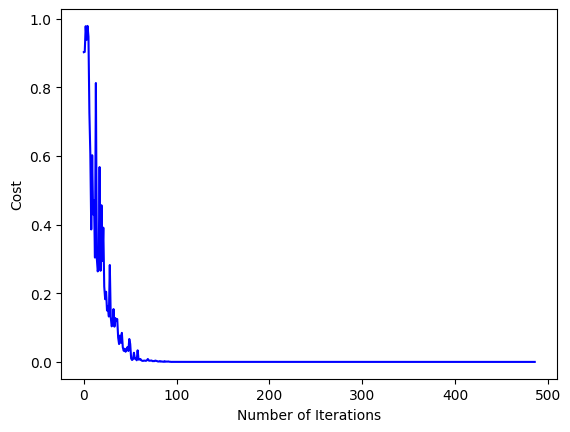

In [13]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [14]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [15]:
e = []
F =[ ]
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(b - Psi/norm)
    f = abs(np.dot(Psi,b))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

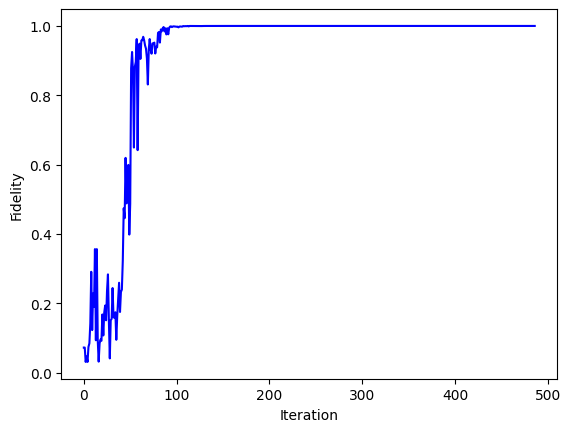

In [16]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


Text(0.5, 0, 'Iteration')

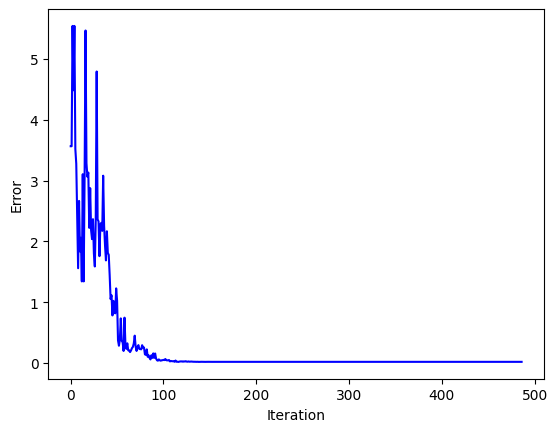

In [18]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [19]:
norm_e[np.argmax(F)]

0.019183823092797658

In [20]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [21]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.01442729, 0.00484753, 0.00456534, 0.01074856])

In [23]:
print(F)

[0.07289369025837973, 0.0728936902583797, 0.03149532954808215, 0.047310743231108246, 0.03149532954808217, 0.07463904548235176, 0.0851339921364683, 0.14248425599206718, 0.29117066539904946, 0.12327264690869219, 0.22879130703645262, 0.1905950346159604, 0.35656931727436886, 0.09389837227830833, 0.356511416592307, 0.09397154608557352, 0.03234138002884589, 0.08471418340193747, 0.09621930970843331, 0.0924453799543259, 0.1681870198416767, 0.1077984419579712, 0.17346088031600373, 0.19394890651808416, 0.15146675287573405, 0.2353623931083625, 0.2837219558366114, 0.15171140653167528, 0.041670945096706345, 0.15170201084433468, 0.15566066325764685, 0.24441837305190972, 0.16111892343753062, 0.15820562632818988, 0.17455405047248695, 0.09526366519395431, 0.16364694711616903, 0.21096351233557575, 0.25960434957171485, 0.17544090327473122, 0.23324995540082155, 0.2398544283841628, 0.32289473703545635, 0.47411229040738995, 0.445726088462387, 0.6194157833759106, 0.4883191188912336, 0.5831341326563718, 0.599